# Q3 — Gaussian Discriminant Analysis
Classifying land cover types from the Statlog Landsat Satellite dataset (6435 samples, 36 features, 6 classes).

In [80]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.1)

def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

def metrics_per_class(y_true, y_pred, classes):
    report = {}
    for cls in classes:
        tp = np.sum((y_pred == cls) & (y_true == cls))
        fp = np.sum((y_pred == cls) & (y_true != cls))
        fn = np.sum((y_pred != cls) & (y_true == cls))
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        report[cls] = dict(precision=precision, recall=recall, f1=f1)
    return report

## Data

In [81]:
data = np.genfromtxt('data.csv', delimiter=',', skip_header=1)
X_all = data[:, :36]          # 36 spectral features
y_all = data[:, 36].astype(int)  # class labels

classes     = np.array([1, 2, 3, 4, 5, 7])
class_names = {1: 'Red Soil', 2: 'Cotton Crop', 3: 'Grey Soil',
               4: 'Damp Grey Soil', 5: 'Soil w/ Veg.', 7: 'Mixture'}

# 80/20 train/test split
np.random.seed(42)
shuffled_idx = np.random.permutation(len(X_all))
split_at     = int(0.8 * len(X_all))

X_train = X_all[shuffled_idx[:split_at]]
y_train = y_all[shuffled_idx[:split_at]]
X_test  = X_all[shuffled_idx[split_at:]]
y_test  = y_all[shuffled_idx[split_at:]]

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print('Class distribution (train):', {class_names[c]: int((y_train == c).sum()) for c in classes})

Train: (5148, 36)  |  Test: (1287, 36)
Class distribution (train): {'Red Soil': 1224, 'Cotton Crop': 561, 'Grey Soil': 1099, 'Damp Grey Soil': 496, 'Soil w/ Veg.': 554, 'Mixture': 1214}


## LDA and QDA Implementation

In [82]:
class LDA:
    """Linear Discriminant Analysis — shared covariance across all classes."""

    def fit(self, X_train, y_train):
        self.classes_ = np.unique(y_train)
        N = len(y_train)

        # Per-class means and priors
        self.class_means_  = {cls: X_train[y_train == cls].mean(0) for cls in self.classes_}
        self.class_priors_ = {cls: (y_train == cls).mean()         for cls in self.classes_}

        # Pooled within-class scatter matrix (shared covariance)
        within_class_scatter = sum(
            (X_train[y_train == cls] - self.class_means_[cls]).T
            @ (X_train[y_train == cls] - self.class_means_[cls])
            for cls in self.classes_
        )
        self.pooled_cov     = within_class_scatter / N
        self.pooled_cov_inv = np.linalg.pinv(self.pooled_cov)
        return self

    def predict(self, X):
        n_samples = X.shape[0]
        n_classes = len(self.classes_)
        scores = np.zeros((n_samples, n_classes))

        for i, cls in enumerate(self.classes_):
            mu = self.class_means_[cls]
            prior = self.class_priors_[cls]

            diff = X - mu                     # shape: (N, d)
            quadratic = np.sum(
                (diff @ self.pooled_cov_inv) * diff,
                axis=1
            )                                 # shape: (N,)

            scores[:, i] = -0.5 * quadratic + np.log(prior)

        return self.classes_[np.argmax(scores, axis=1)]



class QDA:
    """Quadratic Discriminant Analysis — separate covariance per class."""

    def fit(self, X_train, y_train):
        self.classes_      = np.unique(y_train)
        self.class_params_ = {}
        for cls in self.classes_:
            X_cls  = X_train[y_train == cls]
            mean   = X_cls.mean(0)
            cov    = (X_cls - mean).T @ (X_cls - mean) / len(X_cls)
            self.class_params_[cls] = dict(
                mean    = mean,
                cov_inv = np.linalg.pinv(cov),
                log_det = np.linalg.slogdet(cov)[1],  # log|Sigma_k|
                prior   = len(X_cls) / len(y_train)
            )
        return self

    def _class_log_likelihood(self, X, cls):
        params = self.class_params_[cls]

        mean = params['mean']
        cov_inv = params['cov_inv']
        log_det = params['log_det']
        prior = params['prior']

        diff = X - mean                          # (N, d)

        # (x - mu)^T Sigma^-1 (x - mu) for each sample
        temp = diff @ cov_inv                    # (N, d)
        mahal_sq = np.sum(temp * diff, axis=1)   # (N,)

        log_likelihood = -0.5 * (mahal_sq + log_det) + np.log(prior)
        return log_likelihood


    def predict(self, X):
        log_posteriors = np.stack(
            [self._class_log_likelihood(X, cls) for cls in self.classes_], axis=1
        )
        return self.classes_[log_posteriors.argmax(axis=1)]


lda_full = LDA().fit(X_train, y_train)
qda_full = QDA().fit(X_train, y_train)
print(f'LDA accuracy (full 36 features): {accuracy(y_test, lda_full.predict(X_test)):.4f}')
print(f'QDA accuracy (full 36 features): {accuracy(y_test, qda_full.predict(X_test)):.4f}')

LDA accuracy (full 36 features): 0.8430
QDA accuracy (full 36 features): 0.8601


---
## Task 1 — The Geometry of Land Cover

We visualise the learned mean spectral signatures per class, then quantify how separable classes 1 and 3 are using Euclidean vs Mahalanobis distance.

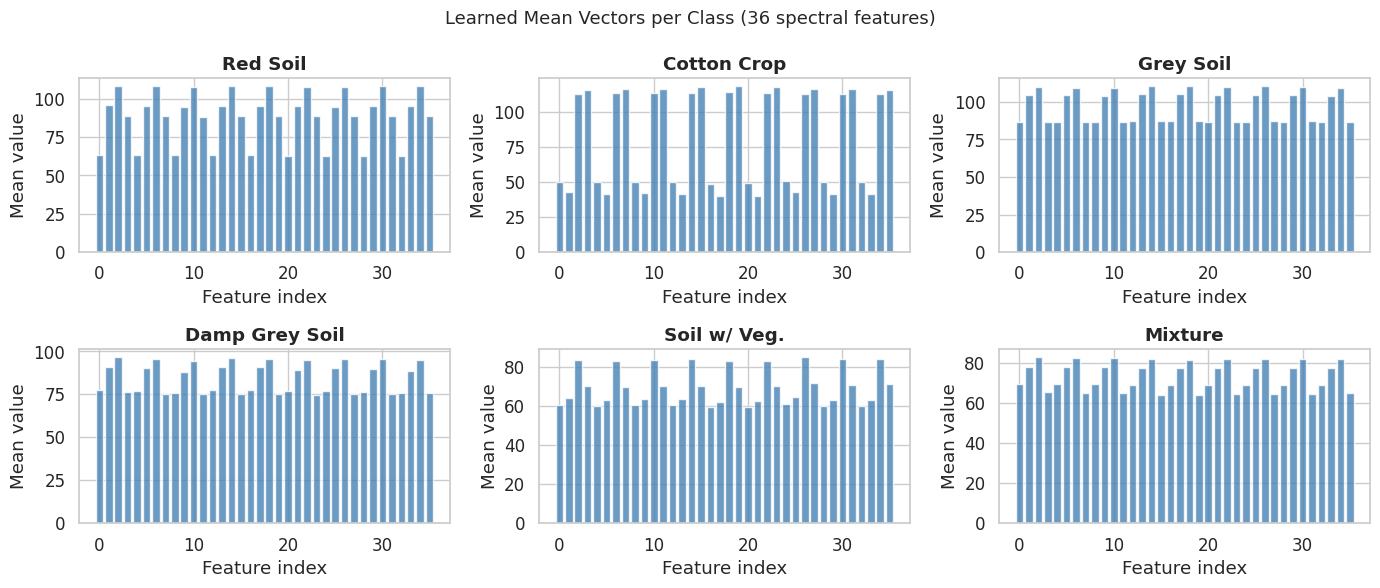

In [83]:
fig, axes = plt.subplots(2, 3, figsize=(14, 6))
fig.suptitle('Learned Mean Vectors per Class (36 spectral features)', fontsize=13)
for ax, cls in zip(axes.flat, classes):
    ax.bar(range(36), lda_full.class_means_[cls], color='steelblue', alpha=0.8)
    ax.set_title(class_names[cls], fontweight='bold')
    ax.set_xlabel('Feature index')
    ax.set_ylabel('Mean value')
plt.tight_layout()
plt.show()

### Distance Analysis — Class 1 (Red Soil) vs Class 3 (Grey Soil)

Euclidean distance treats all 36 features equally, so a single large-scale feature can dominate the result. Mahalanobis distance normalises by the covariance, making it scale-invariant. We verify this by artificially stretching feature 0 by 1000×.

In [84]:
mean_red_soil  = lda_full.class_means_[1]
mean_grey_soil = lda_full.class_means_[3]
mean_diff      = mean_red_soil - mean_grey_soil

euclidean_dist   = np.linalg.norm(mean_diff)
mahalanobis_dist = np.sqrt(mean_diff @ lda_full.pooled_cov_inv @ mean_diff)
print(f'Euclidean   (Red Soil vs Grey Soil): {euclidean_dist:.4f}')
print(f'Mahalanobis (Red Soil vs Grey Soil): {mahalanobis_dist:.4f}')

# Stretch feature 0 by 1000x — Euclidean should explode, Mahalanobis should stay the same
X_train_stretched = X_train.copy()
X_train_stretched[:, 0] *= 1000

lda_stretched   = LDA().fit(X_train_stretched, y_train)
mean_diff_stretched = lda_stretched.class_means_[1] - lda_stretched.class_means_[3]

euclidean_stretched   = np.linalg.norm(mean_diff_stretched)
mahalanobis_stretched = np.sqrt(mean_diff_stretched @ lda_stretched.pooled_cov_inv @ mean_diff_stretched)
print(f'\nAfter stretching feature 0 x 1000:')
print(f'  Euclidean   : {euclidean_stretched:.2f}  <- explodes, dominated by one feature')
print(f'  Mahalanobis : {mahalanobis_stretched:.4f} <- unchanged, scale-invariant')

Euclidean   (Red Soil vs Grey Soil): 77.1807
Mahalanobis (Red Soil vs Grey Soil): 7.0026

After stretching feature 0 x 1000:
  Euclidean   : 23276.23  <- explodes, dominated by one feature
  Mahalanobis : 7.0026 <- unchanged, scale-invariant


**Takeaway:** Mahalanobis is the better metric here. It accounts for correlation and scale across all 36 features, stretching any single feature has no effect on it.

---
## Task 2 — Feature Selection

The 36 features come from a 3×3 pixel neighbourhood (4 spectral bands × 9 pixels). We test 5 subsets to see whether more spatial context actually helps. QDA must estimate K separate D×D covariance matrices, so high D hurts it when data is limited (curse of dimensionality).

In [85]:
# Feature index layout: pixels are ordered row-by-row, 4 bands each
# Indices 0-3: top-left, 4-7: top-center, 8-11: top-right
# Indices 12-15: mid-left, 16-19: center, 20-23: mid-right
# Indices 24-27: bot-left, 28-31: bot-center, 32-35: bot-right
feature_subsets = {
    '1-Pixel (Center, 4)':    list(range(16, 20)),
    '4-Pixels (Corners, 16)': list(range(0,4))  + list(range(8,12)) +
                              list(range(24,28)) + list(range(32,36)),
    '5-Pixels (Cross, 20)':   list(range(0,4))  + list(range(8,12)) +
                              list(range(16,20)) + list(range(24,28)) +
                              list(range(32,36)),
    '6-Pixels (Top 2x3, 24)': list(range(0,4))  + list(range(4,8))  +
                              list(range(8,12))  + list(range(12,16)) +
                              list(range(16,20)) + list(range(20,24)),
    '9-Pixels (Full, 36)':    list(range(36)),
}
subset_labels = list(feature_subsets.keys())
pixel_counts  = [1, 4, 5, 6, 9]

lda_subset_accs, qda_subset_accs = [], []
for subset_name, feat_idx in feature_subsets.items():
    X_tr_sub = X_train[:, feat_idx]
    X_te_sub = X_test[:,  feat_idx]
    lda_subset_accs.append(accuracy(y_test, LDA().fit(X_tr_sub, y_train).predict(X_te_sub)))
    qda_subset_accs.append(accuracy(y_test, QDA().fit(X_tr_sub, y_train).predict(X_te_sub)))

for name, lda_acc, qda_acc in zip(subset_labels, lda_subset_accs, qda_subset_accs):
    print(f'{name:30s}  LDA={lda_acc:.4f}  QDA={qda_acc:.4f}')

1-Pixel (Center, 4)             LDA=0.8151  QDA=0.8438
4-Pixels (Corners, 16)          LDA=0.8197  QDA=0.8430
5-Pixels (Cross, 20)            LDA=0.8376  QDA=0.8578
6-Pixels (Top 2x3, 24)          LDA=0.8376  QDA=0.8656
9-Pixels (Full, 36)             LDA=0.8430  QDA=0.8601


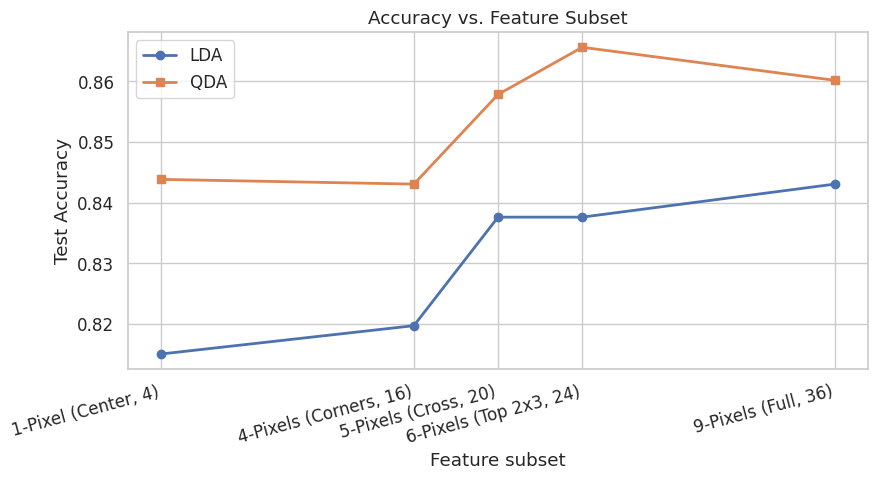

In [86]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(pixel_counts, lda_subset_accs, 'o-', label='LDA', linewidth=2)
ax.plot(pixel_counts, qda_subset_accs, 's-', label='QDA', linewidth=2)
ax.set_xticks(pixel_counts)
ax.set_xticklabels(subset_labels, rotation=15, ha='right')
ax.set_xlabel('Feature subset')
ax.set_ylabel('Test Accuracy')
ax.set_title('Accuracy vs. Feature Subset')
ax.legend()
plt.tight_layout()
plt.show()

**Observations:**
- LDA improves steadily with more pixels — extra spatial context always helps the shared-covariance model.
- QDA plateaus or degrades at 9 pixels. It must estimate K × D × D parameters, so variance in those estimates grows fast with D. Even with ~5000 training samples this starts to show.

---
## Task 3 — Forensic Performance Analysis

In [87]:
y_pred_qda_full = qda_full.predict(X_test)
y_pred_lda_full = lda_full.predict(X_test)
print(f'QDA overall accuracy: {accuracy(y_test, y_pred_qda_full):.4f}')
print(f'LDA overall accuracy: {accuracy(y_test, y_pred_lda_full):.4f}')

QDA overall accuracy: 0.8601
LDA overall accuracy: 0.8430


### Per-Class Report (Full Grid QDA)

In [88]:
class_report = metrics_per_class(y_test, y_pred_qda_full, classes)

print(f'{"Class":<20} {"Precision":>10} {"Recall":>10} {"F1":>10}')
print('-' * 54)
for cls in classes:
    r = class_report[cls]
    print(f'{class_names[cls]:<20} {r["precision"]:>10.4f} {r["recall"]:>10.4f} {r["f1"]:>10.4f}')

Class                 Precision     Recall         F1
------------------------------------------------------
Red Soil                 0.9623     0.9903     0.9761
Cotton Crop              0.9150     0.9859     0.9492
Grey Soil                0.8247     0.9266     0.8727
Damp Grey Soil           0.6600     0.2538     0.3667
Soil w/ Veg.             0.8750     0.8693     0.8721
Mixture                  0.7895     0.8673     0.8266


### Confusion Matrix

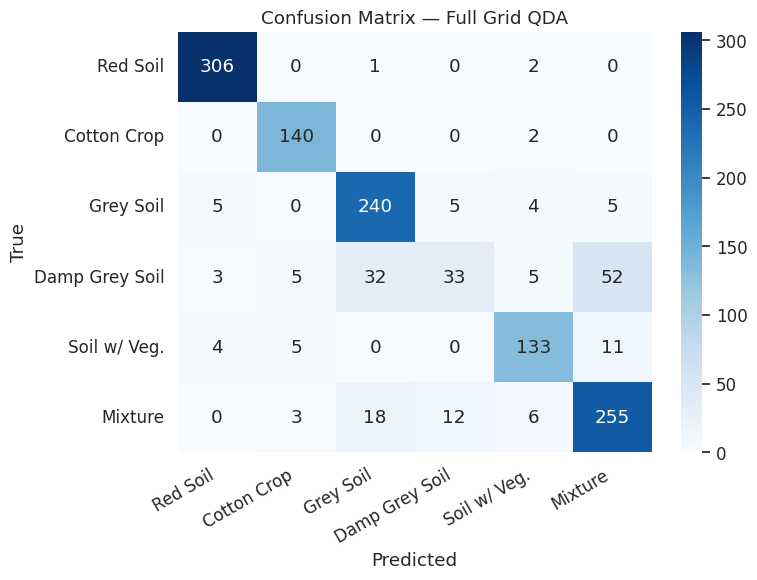

In [89]:
num_classes  = len(classes)
cls_to_idx   = {cls: i for i, cls in enumerate(classes)}
conf_matrix  = np.zeros((num_classes, num_classes), dtype=int)

for true_label, pred_label in zip(y_test, y_pred_qda_full):
    conf_matrix[cls_to_idx[true_label], cls_to_idx[pred_label]] += 1

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=[class_names[c] for c in classes],
            yticklabels=[class_names[c] for c in classes], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix — Full Grid QDA')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### Sample Size Simulation — Finding the LDA/QDA Crossover Point

In [90]:
training_sizes = list(range(100, 4001, 100))
lda_accuracies = []
qda_accuracies = []

for n in training_sizes:
    if n > len(X_train):
        n = len(X_train)

    indices = np.random.choice(len(X_train), n, replace=False)
    X_subset = X_train[indices]
    y_subset = y_train[indices]

    lda_model = LDA().fit(X_subset, y_subset)
    lda_acc = accuracy(y_test, lda_model.predict(X_test))
    lda_accuracies.append(lda_acc)

    try:
        qda_model = QDA().fit(X_subset, y_subset)
        qda_acc = accuracy(y_test, qda_model.predict(X_test))
    except:
        qda_acc = np.nan

    qda_accuracies.append(qda_acc)

crossover_n = None
for i in range(len(training_sizes)):
    if not np.isnan(qda_accuracies[i]) and qda_accuracies[i] > lda_accuracies[i]:
        crossover_n = training_sizes[i]
        break

print("Crossover point (QDA overtakes LDA): N ≈", crossover_n)


Crossover point (QDA overtakes LDA): N ≈ 1300


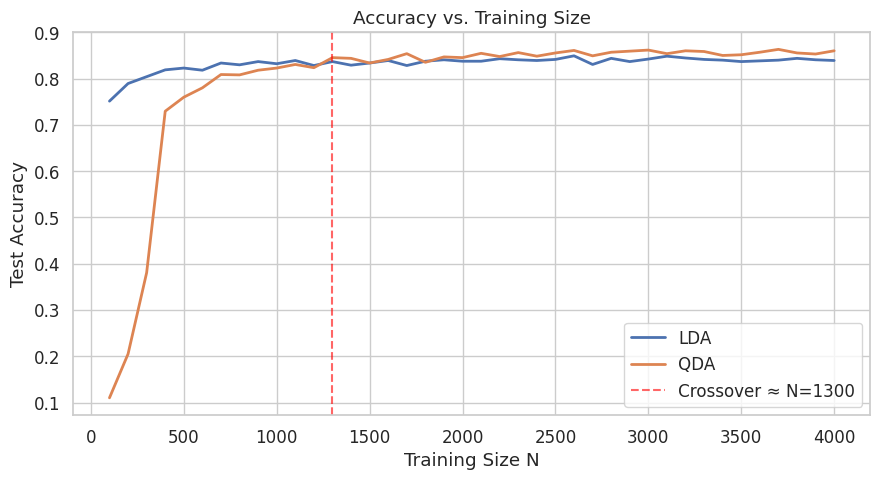

In [91]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(training_sizes, lda_accs_by_size, label='LDA', linewidth=2)
ax.plot(training_sizes, qda_accs_by_size, label='QDA', linewidth=2)
if crossover_n:
    ax.axvline(crossover_n, color='red', linestyle='--', alpha=0.6,
               label=f'Crossover ≈ N={crossover_n}')
ax.set_xlabel('Training Size N')
ax.set_ylabel('Test Accuracy')
ax.set_title('Accuracy vs. Training Size')
ax.legend()
plt.tight_layout()
plt.show()

### Findings

**Hardest class:** Damp Grey Soil (class 4) has the lowest F1. Its mean vector is very close to Grey Soil's, which the distance analysis above predicted.

**Most confused pair:** Grey Soil vs Damp Grey Soil. Nearly identical multispectral signatures; only moisture content differs, causing a small pixel value shift the model struggles to resolve.

**Bias-Variance at small N:** At N=100, LDA beats QDA. QDA estimates K separate full covariance matrices, with little data, this is high variance. LDA's shared pooled covariance acts as a strong regulariser that pays off when samples are scarce. Once N is large enough (crossover point), QDA's extra flexibility starts to win.